In [53]:
# ===================== #
# 1. CARGA DE LIBRERÍAS #
# ===================== #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [54]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)

In [55]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

In [56]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [57]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
]
                                 )

In [58]:
# =============================== #
# VISUALIZACIÓN DEL PREPROCESADOR #
# =============================== #

preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [59]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [60]:
# ==================== #
# 7. MODELO LASSO      #
# ==================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', Lasso())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', Lasso())])

In [61]:
# ============== #
# 10. EVALUACIÓN #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)

MAE: 5469.123912410058
RMSE: 7170.764414320095
MAPE: 0.041600124087716
MAPE(%): 4.160012408771601
R2: 0.9631018713499605


In [62]:
# ======================================== #
# 10.1. DATAFRAME CON RESULTADOS Y ERRORES # 
# ======================================== #

# Asegurar formatos
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

# Construir DataFrame final
df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df

df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)

,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
22378,20,2,3,Product Manager,High School,Telecom,Large,Australia,Hybrid,162569,166429.097395,-3860.097395,3860.097395
12476,18,3,4,Backend Developer,Master,Media,Startup,USA,No,178525,180571.816149,-2046.816149,2046.816149
65503,18,11,5,Software Engineer,Bachelor,Healthcare,Small,Singapore,No,144234,145313.721882,-1079.721882,1079.721882
74914,2,9,5,DevOps Engineer,Master,Manufacturing,Startup,USA,Yes,147687,159990.423230,-12303.423230,12303.423230
9107,1,18,3,AI Engineer,Diploma,Consulting,Small,UK,Yes,146320,155144.563517,-8824.563517,8824.563517
71884,14,19,1,Machine Learning Engineer,Diploma,Telecom,Startup,Canada,Yes,177693,177262.007754,430.992246,430.992246
7746,14,16,3,Data Analyst,PhD,Telecom,Enterprise,India,Hybrid,111932,129072.752929,-17140.752929,17140.752929
14726,15,14,5,Cloud Engineer,Master,Media,Large,Netherlands,Hybrid,181078,182653.695422,-1575.695422,1575.695422
69245,18,5,5,Backend Developer,PhD,Finance,Enterprise,UK,No,228074,215941.781339,12132.218661,12132.218661
28825,2,5,1,Software Engineer,Master,Consulting,Startup,UK,No,117764,115166.741461,2597.258539,2597.258539


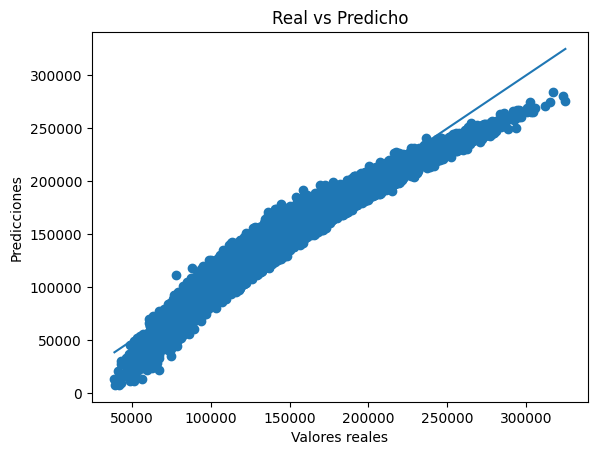

In [63]:
# ====================== #
# 10.2. REAL VS PREDICHO #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# Línea ideal
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)

plt.show()

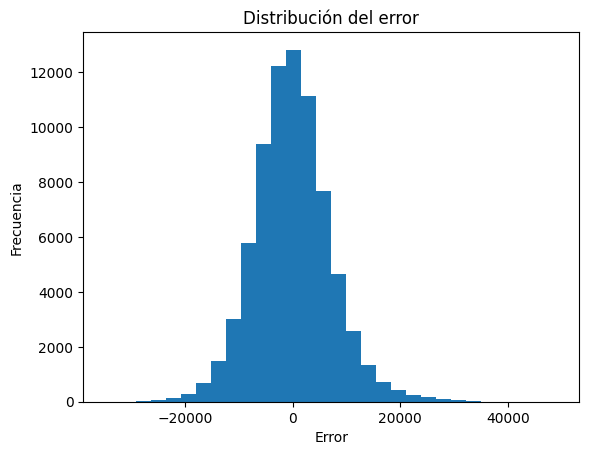

In [64]:
# ============================= #
# 10.3. DISTRIBUCIÓN DE ERRORES #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

In [65]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
# Cambiamos 'model' por 'model_lasso'
cv_results = cross_validate(model, X_train, y_train, cv=10, scoring=scoring)

print("--- RESULTADOS LASSO (10-FOLD) ---")
print(f"MAE  Promedio: {-cv_results['test_mae'].mean():.4f} (Std: {cv_results['test_mae'].std():.4f})")
print(f"RMSE Promedio: {-cv_results['test_rmse'].mean():.4f} (Std: {cv_results['test_rmse'].std():.4f})")
print(f"R²   Promedio: {cv_results['test_r2'].mean():.4f} (Std: {cv_results['test_r2'].std():.4f})")

--- RESULTADOS LASSO (10-FOLD) ---
MAE  Promedio: 5463.2454 (Std: 20.9681)
RMSE Promedio: 7155.4301 (Std: 35.9548)
R²   Promedio: 0.9635 (Std: 0.0004)
